In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import os
print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'Getting started.pdf', 't-tp-2548796-design-a-pizza-cutting-skills-activity-english_ver_2.pdf', 't-tp-6871-design-a-heart-activity-sheet.pdf', 'IMG_1469.png', 'transfer-2024-01-15-12-17-27', 'My Video (1).mp4', 'My Video.mp4', '2022-03-09-0005 (1).jpg', '2022-03-09-0006.jpg', '2022-03-09-0007 (2).jpg', '2022-03-09-0008.jpg', '2022-03-09-0009 (3).jpg', '2022-03-09-0010 (1).jpg', '2022-03-09-0009 (2).jpg', '2022-03-09-0010.jpg', '2022-03-09-0012.jpg', '2022-03-09-0015 (2).jpg', '2022-03-09-0014.jpg', '2022-03-09-0013 (2).jpg', '2022-03-09-0018 (1).jpg', '2022-03-09-0017 (2).jpg', '2022-03-09-0016 (1).jpg', '2022-03-09-0020 (2).jpg', '2022-03-09-0019 (2).jpg', '2022-03-09-0022 (1).jpg', '2022-03-09-0023 (2).jpg', '2022-03-09-0025 (5).jpg', '2022-03-09-0025 (4).jpg', '2022-03-09-0023 (1).jpg', '2022-03-09-0025 (3).jpg', '2022-03-09-0026 (2).jpg', '2022-03-09-0027 (2).jpg', '2022-03-09-0029 (3).jpg', '2022-03-09-0031 (2).jpg', '2022-03-09-0032.jpg', '2022-03-09-0035 (4).

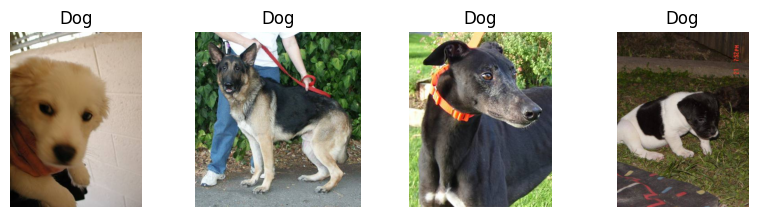

In [8]:
import matplotlib.pyplot as plt
import os
import random
from PIL import Image

def show_images(folder, label):
    images = os.listdir(folder)
    selected = random.sample(images, 4)

    for i, img_name in enumerate(selected):
        img = Image.open(os.path.join(folder, img_name))
        plt.subplot(2, 4, i+1)
        plt.imshow(img)
        plt.title(label)
        plt.axis('off')

plt.figure(figsize=(10,5))
show_images('/content/drive/MyDrive/catdog/dataset/test_set/cats', 'Cat')
show_images('/content/drive/MyDrive/catdog/dataset/test_set/dogs', 'Dog')
plt.show()

In [10]:
cat_count = len(os.listdir('/content/drive/MyDrive/catdog/dataset/test_set/cats'))
dog_count = len(os.listdir('/content/drive/MyDrive/catdog/dataset/test_set/dogs'))

print("Cat:", cat_count)
print("Dog:", dog_count)

Cat: 1000
Dog: 1000


In [12]:
import os
from PIL import Image

widths = []
heights = []

cat_path = '/content/drive/MyDrive/catdog/dataset/test_set/cats'
dog_path = '/content/drive/MyDrive/catdog/dataset/test_set/dogs'

for folder_path in [cat_path, dog_path]:

    for img_name in os.listdir(folder_path):

        img_path = os.path.join(folder_path, img_name)

        try:
            img = Image.open(img_path)
            w, h = img.size

            widths.append(w)
            heights.append(h)
        except:
            continue   # skip corrupted files if any

print("Min Width:", min(widths))
print("Max Width:", max(widths))
print("Avg Width:", sum(widths)//len(widths))

print("Min Height:", min(heights))
print("Max Height:", max(heights))
print("Avg Height:", sum(heights)//len(heights))

Min Width: 59
Max Width: 500
Avg Width: 404
Min Height: 33
Max Height: 500
Avg Height: 360


In [13]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)
base_path = '/content/drive/MyDrive/catdog/dataset'

train_data = datagen.flow_from_directory(
    base_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    base_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 8002 images belonging to 3 classes.
Found 2000 images belonging to 3 classes.


In [17]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 1347s 5s/step - accuracy: 0.1995 - loss: -199902816.0000 - val_accuracy: 0.2000 - val_loss: -1137505152.0000
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 46s 182ms/step - accuracy: 0.2000 - loss: -9042650112.0000 - val_accuracy: 0.2000 - val_loss: -24509806592.0000
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 47s 186ms/step - accuracy: 0.2000 - loss: -68452458496.0000 - val_accuracy: 0.2000 - val_loss: -131204890624.0000
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 47s 186ms/step - accuracy: 0.2000 - loss: -253516578816.0000 - val_accuracy: 0.2000 - val_loss: -406138454016.0000
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 47s 189ms/step - accuracy: 0.2000 - loss: -652667650048.0000 - val_accuracy: 0.2000 - val_loss: -944603791360.0000
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 46s 183ms/step - accuracy: 0.2000 - loss: -1381555634176.0000 - val_accuracy: 0.2000 - val_loss: -1853660200960.0000
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 46s 184ms/step - accuracy: 0.2000 - lo

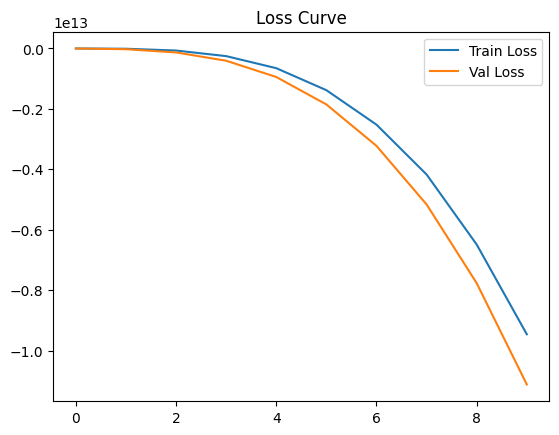

In [18]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 82944)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    10,616,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,909,445 (121.72 MB)

 Trainable params: 10,636,481 (40.57 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 21,272,964 (81.15 MB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step


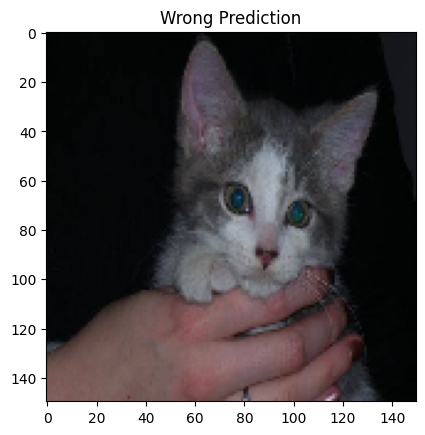

In [20]:

import numpy as np

for images, labels in val_data:
    preds = model.predict(images)
    for i in range(len(images)):
        if round(preds[i][0]) != labels[i]:
            plt.imshow(images[i])
            plt.title("Wrong Prediction")
            plt.show()
            break
    break

In [21]:
layers.Conv2D(128, (3,3), activation='relu'),
layers.MaxPooling2D(2,2),

(<MaxPooling2D name=max_pooling2d_2, built=True>,)